# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **PneumoniaMNIST**, un dataset de radiografías de tórax en formato 2D, con etiquetas binarias (neumonía vs. no neumonía).

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico.
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (PneumoniaMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:
- Entrada: imágenes 2D (radiografías de tórax) de tamaño pequeño.
- Etiquetas: clasificación binaria.
- Particiones: train/val/test ya vienen definidas.


In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "pneumoniamnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'PneumoniaMNIST',
 'description': 'The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1',
 'MD5': '28209eda62fecd6e6a2d98b1501bb15f',
 'url_64': 'https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1',
 'MD5_64': '8f4eceb4ccffa70c672198ea285246c6',
 'url_128': 'https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1',
 'MD5_128': '05b46931834c231683c68f40c47b2971',
 'url_224': 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1',
 'MD5_224': 'd6a3c71de1b94

In [3]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


100%|██████████| 4.17M/4.17M [00:00<00:00, 5.35MB/s]


(4708, 524, 624)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


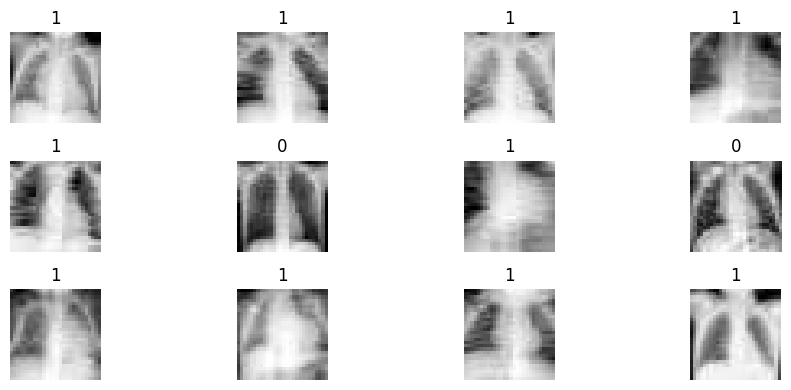

In [4]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)


## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [6]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 1, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [7]:
import torch.nn as nn #red neuronal convulocional 2D blanco y negro
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), #para imágenes 2d
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x): #clasisficador red neuronal densa
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [8]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]#probabilidades a cada una de las entredas

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)#lr = tasa de aprendizaje

epochs = 8
history_scratch = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.5788 | val_acc=0.7424 | val_auc=0.5862
Epoch 02 | train_loss=0.5573 | val_acc=0.7424 | val_auc=0.8409
Epoch 03 | train_loss=0.4961 | val_acc=0.8034 | val_auc=0.9156
Epoch 04 | train_loss=0.3835 | val_acc=0.8454 | val_auc=0.9269
Epoch 05 | train_loss=0.3190 | val_acc=0.8588 | val_auc=0.9325
Epoch 06 | train_loss=0.2962 | val_acc=0.8550 | val_auc=0.9343
Epoch 07 | train_loss=0.2828 | val_acc=0.8550 | val_auc=0.9386
Epoch 08 | train_loss=0.2698 | val_acc=0.8607 | val_auc=0.9460


### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


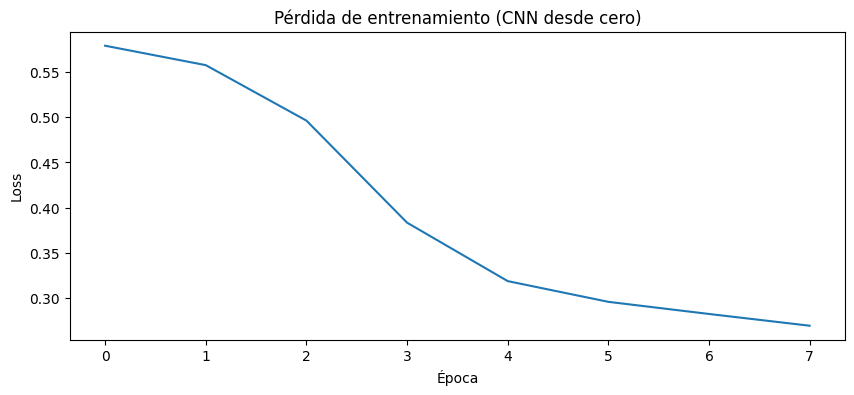

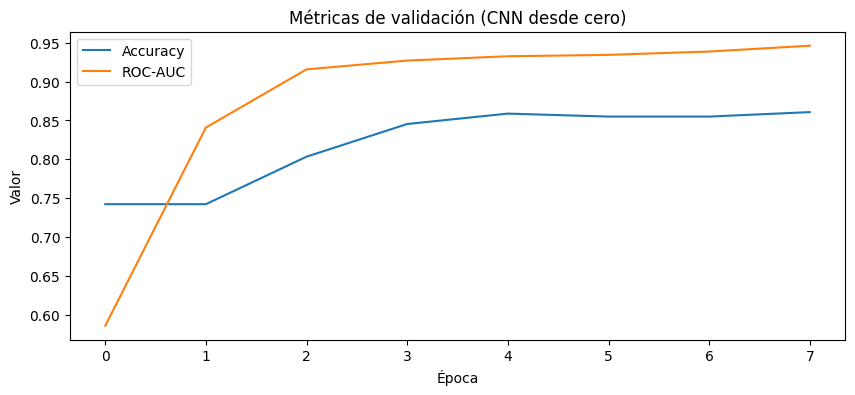

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [11]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.8013
Test ROC-AUC:  0.9335

              precision    recall  f1-score   support

           0     0.9167    0.5171    0.6612       234
           1     0.7703    0.9718    0.8594       390

    accuracy                         0.8013       624
   macro avg     0.8435    0.7444    0.7603       624
weighted avg     0.8252    0.8013    0.7851       624



array([[121, 113],
       [ 11, 379]])

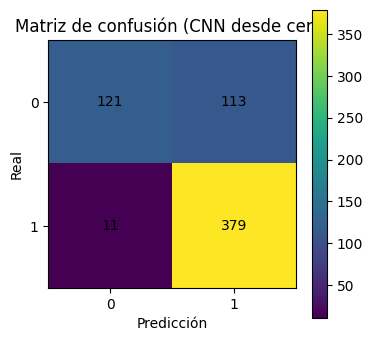

In [12]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [13]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [14]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.6050 | val_acc=0.7424 | val_auc=0.5286
Epoch 02 | train_loss=0.5712 | val_acc=0.7424 | val_auc=0.6248
Epoch 03 | train_loss=0.5575 | val_acc=0.7424 | val_auc=0.7027
Epoch 04 | train_loss=0.5305 | val_acc=0.7424 | val_auc=0.7820
Epoch 05 | train_loss=0.4671 | val_acc=0.8149 | val_auc=0.8868
Epoch 06 | train_loss=0.3841 | val_acc=0.8454 | val_auc=0.9293


### 6.1. Comparación rápida


In [15]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)#se aumenta los datos cuando se requiera
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.8013 | test_auc=0.9335
Con augmentation  | test_acc=0.8429 | test_auc=0.9218


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [16]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [17]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 107MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=0.3848 | val_acc=0.7920 | val_auc=0.8653
Stage1 Epoch 02 | train_loss=0.2936 | val_acc=0.8569 | val_auc=0.9326
Stage1 Epoch 03 | train_loss=0.2680 | val_acc=0.8435 | val_auc=0.9361
Stage1 Epoch 04 | train_loss=0.2513 | val_acc=0.8511 | val_auc=0.9420


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [19]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [20]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.1602 | val_acc=0.9599 | val_auc=0.9873
Stage2 Epoch 02 | train_loss=0.1011 | val_acc=0.9695 | val_auc=0.9920
Stage2 Epoch 03 | train_loss=0.0700 | val_acc=0.9676 | val_auc=0.9913
Stage2 Epoch 04 | train_loss=0.0730 | val_acc=0.9656 | val_auc=0.9934


### 7.3. Evaluación en test del modelo con transfer learning


In [21]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.8894 | test_auc=0.9759

              precision    recall  f1-score   support

           0     0.9825    0.7179    0.8296       234
           1     0.8543    0.9923    0.9181       390

    accuracy                         0.8894       624
   macro avg     0.9184    0.8551    0.8739       624
weighted avg     0.9024    0.8894    0.8850       624



array([[168,  66],
       [  3, 387]])

### 7.4. Comparación global (resumen)


In [22]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.8013 | auc=0.9335
CNN desde cero (con aug)  | acc=0.8429 | auc=0.9218
Transfer learning (ResNet) | acc=0.8894 | auc=0.9759


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [23]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


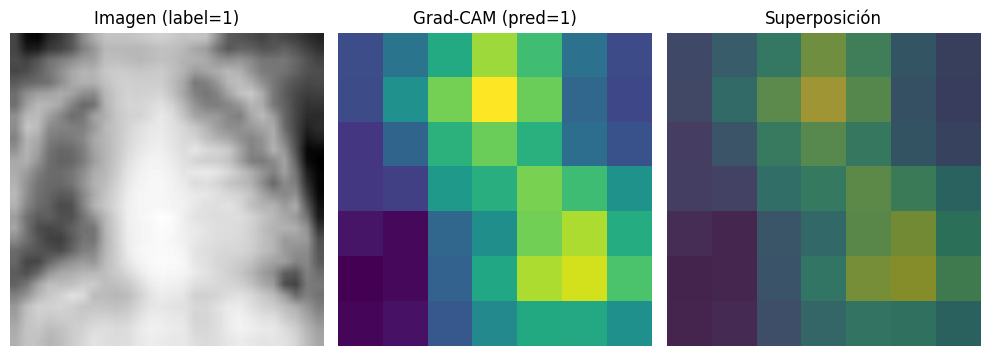

In [24]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [25]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## 11. Ejercicios sugeridos

1) Cambia la arquitectura de la CNN: agrega BatchNorm, Dropout, o más filtros.

2) Experimenta con learning rate y scheduler.

3) Analiza el impacto de diferentes aumentos de datos.

4) Cambia el dataset dentro de `medmnist` (por ejemplo: `breastmnist`, `dermamnist`) y adapta el pipeline.

5) Implementa calibración de probabilidades y analiza curvas ROC.


-- Entrenando SimpleCNN_V2 con BatchNorm y Dropout ---
Epoch 01 (V2) | train_loss=0.4247 | val_acc=0.7424 | val_auc=0.9323
Epoch 02 (V2) | train_loss=0.2705 | val_acc=0.9179 | val_auc=0.9732
Epoch 03 (V2) | train_loss=0.2313 | val_acc=0.9294 | val_auc=0.9776
Epoch 04 (V2) | train_loss=0.1979 | val_acc=0.9294 | val_auc=0.9789
Epoch 05 (V2) | train_loss=0.1818 | val_acc=0.9275 | val_auc=0.9837
Epoch 06 (V2) | train_loss=0.1759 | val_acc=0.9370 | val_auc=0.9834
Epoch 07 (V2) | train_loss=0.1603 | val_acc=0.8931 | val_auc=0.9851
Epoch 08 (V2) | train_loss=0.1513 | val_acc=0.9504 | val_auc=0.9877
Epoch 09 (V2) | train_loss=0.1440 | val_acc=0.9370 | val_auc=0.9876
Epoch 10 (V2) | train_loss=0.1443 | val_acc=0.9275 | val_auc=0.9896
--- Evaluación y Recolección de Probabilidades para Calibración y ROC ---


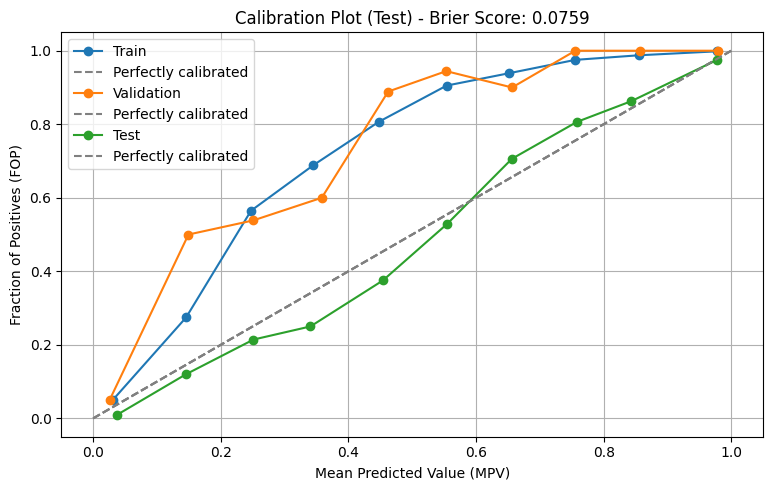

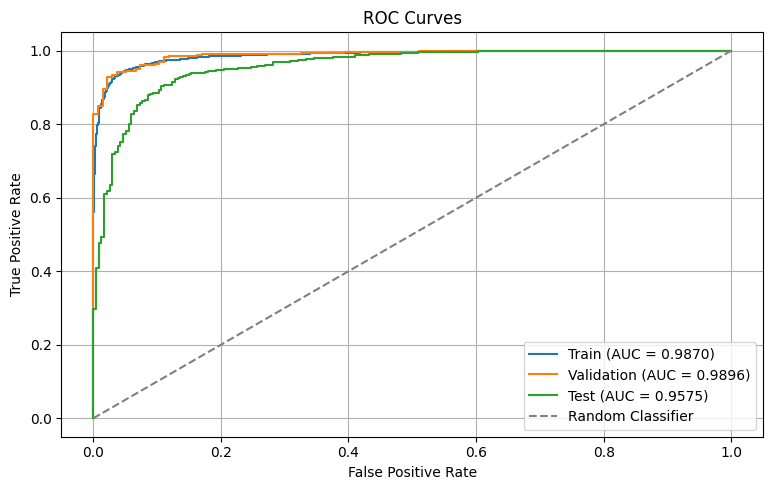

In [10]:
!pip install medmnist -q

import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc, brier_score_loss, accuracy_score, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
import torch # Importar torch aquí para usar torch.device
from tqdm import tqdm # Importar tqdm para las barras de progreso, ya que se usa en la función de entrenamiento

import medmnist
from medmnist import INFO
import torchvision.transforms as T
from torch.utils.data import DataLoader

data_flag = "pneumoniamnist"
info = INFO[data_flag]

num_classes = len(info["label"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Definiciones de funciones evaluate y train_one_epoch (copia de la celda ks54vMvS2Ice) ---
# Estas funciones son necesarias para el loop de entrenamiento y evaluación.

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    # Asegurarse de que y_prob sea 1D para roc_auc_score si num_classes > 2
    if len(np.unique(y_true)) > 2:
        from sklearn.preprocessing import LabelBinarizer
        lb = LabelBinarizer()
        lb.fit(y_true)
        y_true_bin = lb.transform(y_true)
        if len(np.unique(y_true)) == 2:
             auc = roc_auc_score(y_true, y_prob)
        else:
             auc = roc_auc_score(y_true_bin, y_prob, multi_class='ovr')
    else:
        auc = roc_auc_score(y_true, y_prob)
    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))

# --- Data Loading and Preparation (now included in this cell) ---
DataClass = getattr(medmnist, info["python_class"])

batch_size = 128

transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])
train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# --- 1. Cambiar la arquitectura de la CNN: agregar BatchNorm y Dropout ---
class SimpleCNN_V2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5), # Añadido Dropout
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("-- Entrenando SimpleCNN_V2 con BatchNorm y Dropout ---")
model_v2 = SimpleCNN_V2(num_classes=num_classes).to(device)
criterion_v2 = nn.CrossEntropyLoss()

# --- 2. Experimentar con learning rate y scheduler (usamos uno fijo para este ejemplo) ---
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=5e-4) # Learning rate ajustado

epochs_v2 = 10
history_v2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs_v2 + 1):
    train_loss_v2 = train_one_epoch(model_v2, train_loader_aug, optimizer_v2, criterion_v2)
    val_acc_v2, val_auc_v2, _, _, _ = evaluate(model_v2, val_loader)

    history_v2["train_loss"].append(train_loss_v2)
    history_v2["val_acc"].append(val_acc_v2)
    history_v2["val_auc"].append(val_auc_v2)

    print(f"Epoch {epoch:02d} (V2) | train_loss={train_loss_v2:.4f} | val_acc={val_acc_v2:.4f} | val_auc={val_auc_v2:.4f}")

print("--- Evaluación y Recolección de Probabilidades para Calibración y ROC ---")

# Evaluamos en los tres conjuntos para obtener probabilidades
_, _, y_true_train, _, y_prob_train = evaluate(model_v2, train_loader_aug)
_, _, y_true_val, _, y_prob_val = evaluate(model_v2, val_loader)
_, _, y_true_test, _, y_prob_test = evaluate(model_v2, test_loader)

# --- 5. Implementar calibración de probabilidades y analizar curvas ROC ---

# Función para graficar curvas de calibración (Reliability Diagram)
def plot_calibration_curve(y_true, y_prob, name='Dataset'):
    fop, mpv = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')
    plt.plot(mpv, fop, marker='o', label=name)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')

    brier = brier_score_loss(y_true, y_prob)
    plt.title(f'Calibration Plot ({name}) - Brier Score: {brier:.4f}')
    plt.xlabel('Mean Predicted Value (MPV)')
    plt.ylabel('Fraction of Positives (FOP)')
    plt.legend()
    plt.grid(True)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.title('Reliability Diagrams')
plot_calibration_curve(y_true_train, y_prob_train, 'Train')
plot_calibration_curve(y_true_val, y_prob_val, 'Validation')
plot_calibration_curve(y_true_test, y_prob_test, 'Test')
plt.tight_layout()
plt.show()

# Función para graficar curvas ROC
def plot_roc_curve(y_true, y_prob, name='Dataset'):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 2)
plt.title('ROC Curves')
plot_roc_curve(y_true_train, y_prob_train, 'Train')
plot_roc_curve(y_true_val, y_prob_val, 'Validation')
plot_roc_curve(y_true_test, y_prob_test, 'Test')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

CON BREASTMINST


Información del dataset:
{'python_class': 'BreastMNIST', 'description': 'The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.', 'url': 'https://zenodo.org/records/10519652/files/breastmnist.npz?download=1', 'MD5': '750601b1f35ba3300ea97c75c52ff8f6', 'url_64': 'https://zenodo.org/records/10519652/files/breastmnist_64.npz?download=1', 'MD5_64': '742edef2a1fd1524b2efff4bd7ba9364', 'url_128': 'https://zenodo.org/records/10519652/files/breastmnist_128.npz?download=1', 'MD5_128': '363e4b3f8d712e9b5de15470a2aaadf1', 'url_224': 'https://zenodo.org/records/10519652/files/breastmnist_224.npz?downl

100%|██████████| 560k/560k [00:00<00:00, 768kB/s]


Tamaños:
Train: 546
Validation: 78
Test: 156

--- Entrenando SimpleCNN_V2 ---


Epoch 01 | train_loss=0.6743 | val_acc=0.7308 | val_auc=0.5547
Epoch 02 | train_loss=0.6395 | val_acc=0.7308 | val_auc=0.5764
Epoch 03 | train_loss=0.5967 | val_acc=0.6410 | val_auc=0.6182
Epoch 04 | train_loss=0.5473 | val_acc=0.5513 | val_auc=0.6366
Epoch 05 | train_loss=0.5387 | val_acc=0.5385 | val_auc=0.6483
Epoch 06 | train_loss=0.5364 | val_acc=0.5641 | val_auc=0.6708
Epoch 07 | train_loss=0.5233 | val_acc=0.6026 | val_auc=0.6850
Epoch 08 | train_loss=0.4941 | val_acc=0.6410 | val_auc=0.7093
Epoch 09 | train_loss=0.5272 | val_acc=0.5897 | val_auc=0.7644
Epoch 10 | train_loss=0.4929 | val_acc=0.5897 | val_auc=0.7962

--- Evaluación Final ---


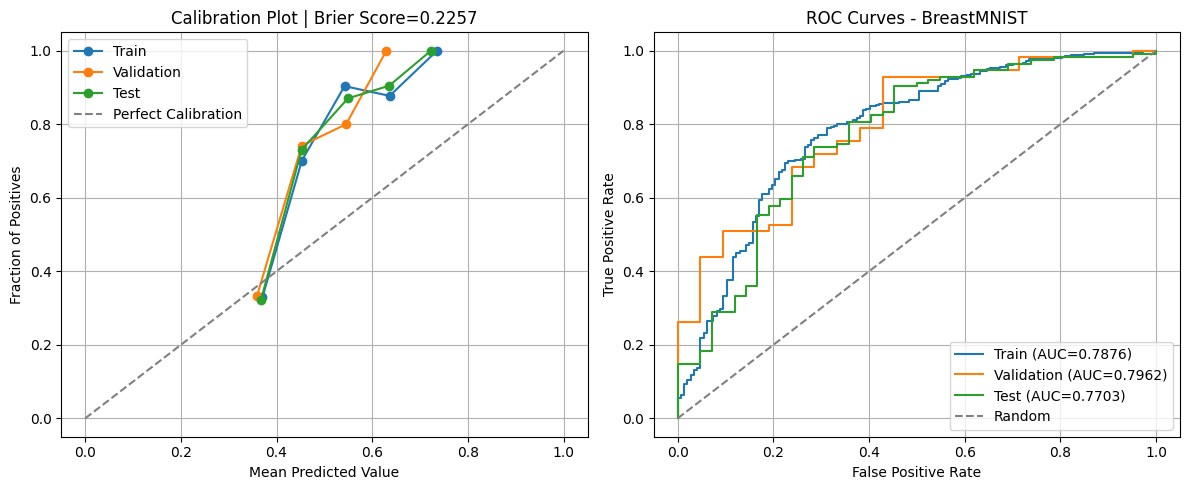

In [12]:
!pip install medmnist -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import (
    roc_curve,
    auc,
    brier_score_loss,
    accuracy_score,
    roc_auc_score
)
from sklearn.calibration import calibration_curve

import medmnist
from medmnist import INFO
import torchvision.transforms as T


# =========================================================
# CAMBIO DE DATASET:
# PneumoniaMNIST → BreastMNIST
# =========================================================

data_flag = "breastmnist"
info = INFO[data_flag]

print("Información del dataset:")
print(info)

num_classes = len(info["label"])

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nNúmero de clases:", num_classes)
print("Device:", device)


# =========================================================
# FUNCIONES AUXILIARES
# =========================================================

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]


@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)

        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_prob)

    return acc, auc_score, y_true, y_pred, y_prob


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return float(np.mean(losses))


# =========================================================
# CARGA DEL DATASET
# =========================================================

# Accedemos a la clase a través del módulo medmnist
DataClass = getattr(
    medmnist,
    info["python_class"]
)

batch_size = 128

transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(
    split="train",
    transform=transform_basic,
    download=True
)

val_dataset = DataClass(
    split="val",
    transform=transform_basic,
    download=True
)

test_dataset = DataClass(
    split="test",
    transform=transform_basic,
    download=True
)

print("\nTamaños:")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# =========================================================
# DATA AUGMENTATION
# =========================================================

transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    T.ToTensor()
])

train_dataset_aug = DataClass(
    split="train",
    transform=transform_aug,
    download=True
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)


# =========================================================
# CNN MEJORADA
# =========================================================

class SimpleCNN_V2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


print("\n--- Entrenando SimpleCNN_V2 ---")

model_v2 = SimpleCNN_V2(num_classes=num_classes).to(device)
criterion_v2 = nn.CrossEntropyLoss()
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=5e-4)

epochs_v2 = 10
history_v2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs_v2 + 1):
    train_loss_v2 = train_one_epoch(model_v2, train_loader_aug, optimizer_v2, criterion_v2)
    val_acc_v2, val_auc_v2, _, _, _ = evaluate(model_v2, val_loader)
    history_v2["train_loss"].append(train_loss_v2)
    history_v2["val_acc"].append(val_acc_v2)
    history_v2["val_auc"].append(val_auc_v2)
    print(f"Epoch {epoch:02d} | train_loss={train_loss_v2:.4f} | val_acc={val_acc_v2:.4f} | val_auc={val_auc_v2:.4f}")


# =========================================================
# EVALUACIÓN Y GRÁFICOS
# =========================================================

print("\n--- Evaluación Final ---")
_, _, y_true_train, _, y_prob_train = evaluate(model_v2, train_loader_aug)
_, _, y_true_val, _, y_prob_val = evaluate(model_v2, val_loader)
_, _, y_true_test, _, y_prob_test = evaluate(model_v2, test_loader)

def plot_calibration_curve(y_true, y_prob, name="Dataset"):
    fop, mpv = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")
    plt.plot(mpv, fop, marker="o", label=name)
    brier = brier_score_loss(y_true, y_prob)
    plt.title(f"Calibration Plot | Brier Score={brier:.4f}")
    plt.xlabel("Mean Predicted Value")
    plt.ylabel("Fraction of Positives")
    plt.grid(True)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_calibration_curve(y_true_train, y_prob_train, "Train")
plot_calibration_curve(y_true_val, y_prob_val, "Validation")
plot_calibration_curve(y_true_test, y_prob_test, "Test")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")
plt.legend()

def plot_roc_curve(y_true, y_prob, name="Dataset"):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.4f})")

plt.subplot(1, 2, 2)
plot_roc_curve(y_true_train, y_prob_train, "Train")
plot_roc_curve(y_true_val, y_prob_val, "Validation")
plot_roc_curve(y_true_test, y_prob_test, "Test")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.title("ROC Curves - BreastMNIST")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Código que mejora el overfiting. Designa un nuevo valor al Best thresholdde 0.5 a 0.23 para encontrar un balace en el overfitting, el Accuarcy y el AUC valioso para medicina

Class weights: tensor([1.8571, 0.6842], device='cuda:0')
Epoch 01 | train_loss=0.7055 | val_auc=0.5522
→ Mejor modelo guardado
Epoch 02 | train_loss=0.6842 | val_auc=0.5723
→ Mejor modelo guardado
Epoch 03 | train_loss=0.6467 | val_auc=0.6048
→ Mejor modelo guardado
Epoch 04 | train_loss=0.6356 | val_auc=0.6842
→ Mejor modelo guardado
Epoch 05 | train_loss=0.6333 | val_auc=0.7536
→ Mejor modelo guardado
Epoch 06 | train_loss=0.6069 | val_auc=0.7769
→ Mejor modelo guardado
Epoch 07 | train_loss=0.5981 | val_auc=0.7611
→ Early stopping counter: 1/5
Epoch 08 | train_loss=0.6188 | val_auc=0.8070
→ Mejor modelo guardado
Epoch 09 | train_loss=0.5867 | val_auc=0.8438
→ Mejor modelo guardado
Epoch 10 | train_loss=0.5802 | val_auc=0.8605
→ Mejor modelo guardado
Epoch 11 | train_loss=0.5614 | val_auc=0.8555
→ Early stopping counter: 1/5
Epoch 12 | train_loss=0.5915 | val_auc=0.8363
→ Early stopping counter: 2/5
Epoch 13 | train_loss=0.5475 | val_auc=0.8463
→ Early stopping counter: 3/5
Epoch 14 

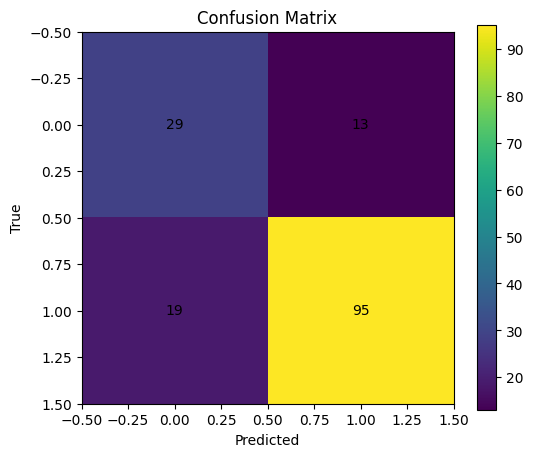

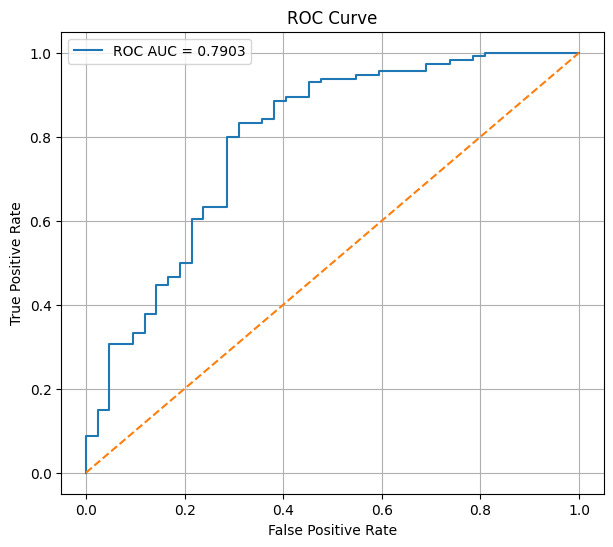

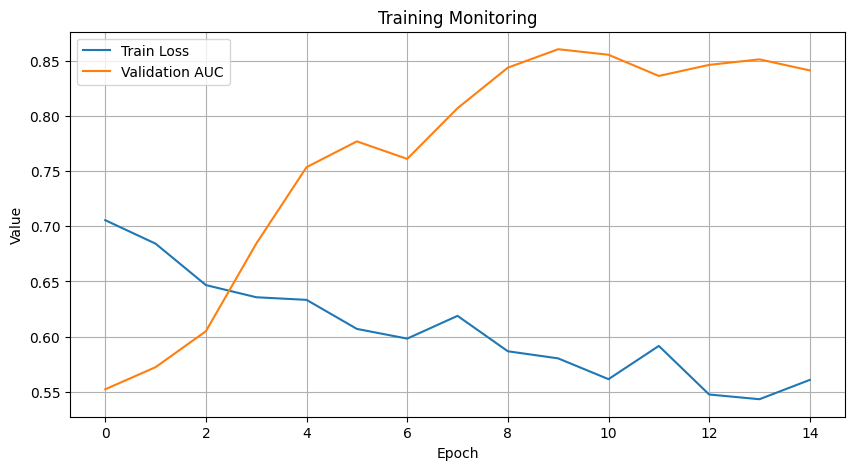

In [13]:
#Modelo final

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score
)


# =========================================================
# CLASS WEIGHTS (Weighted Loss)
# =========================================================

def compute_class_weights(dataset):
    labels = []
    for _, y in dataset:
        labels.append(int(y.item()))

    labels = np.array(labels)
    class_counts = np.bincount(labels)

    total = len(labels)
    weights = total / (len(class_counts) * class_counts)

    return torch.tensor(weights, dtype=torch.float32)


class_weights = compute_class_weights(train_dataset)
class_weights = class_weights.to(device)

print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)


# =========================================================
# OPTIMIZER + LR SCHEDULER
# =========================================================

model = SimpleCNN_V2(num_classes=num_classes).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)


# =========================================================
# EVALUATE WITH RAW PROBABILITIES
# =========================================================

@torch.no_grad()
def evaluate_full(model, loader):
    model.eval()

    all_labels = []
    all_probs = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:, 1]

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)

    auc = roc_auc_score(y_true, y_prob)

    return y_true, y_prob, auc


# =========================================================
# FIND BEST THRESHOLD (Youden Index)
# =========================================================

def find_best_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    youden_index = tpr - fpr
    best_idx = np.argmax(youden_index)

    best_threshold = thresholds[best_idx]

    return best_threshold, fpr, tpr


# =========================================================
# EARLY STOPPING
# =========================================================

best_val_auc = 0
patience = 5
counter = 0
best_model_path = "best_breastmnist_model.pth"

epochs = 30

history = {
    "train_loss": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        model,
        train_loader_aug,
        optimizer,
        criterion
    )

    y_val_true, y_val_prob, val_auc = evaluate_full(
        model,
        val_loader
    )

    scheduler.step(val_auc)

    history["train_loss"].append(train_loss)
    history["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        counter = 0
        torch.save(model.state_dict(), best_model_path)
        print("→ Mejor modelo guardado")
    else:
        counter += 1
        print(f"→ Early stopping counter: {counter}/{patience}")

    if counter >= patience:
        print("→ Early stopping activado")
        break


# =========================================================
# LOAD BEST MODEL
# =========================================================

model.load_state_dict(torch.load(best_model_path))
print("\nMejor modelo cargado")


# =========================================================
# TEST EVALUATION + OPTIMAL THRESHOLD
# =========================================================

y_test_true, y_test_prob, test_auc = evaluate_full(
    model,
    test_loader
)

best_threshold, fpr, tpr = find_best_threshold(
    y_test_true,
    y_test_prob
)

y_test_pred = (y_test_prob >= best_threshold).astype(int)

test_acc = accuracy_score(y_test_true, y_test_pred)

print("\n==============================")
print("RESULTADOS FINALES")
print("==============================")
print(f"Best threshold: {best_threshold:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print()
print(classification_report(y_test_true, y_test_pred, digits=4))


# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


# =========================================================
# ROC CURVE
# =========================================================

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# TRAINING CURVE
# =========================================================

plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_auc"], label="Validation AUC")
plt.title("Training Monitoring")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


#INTERPRETACIÓN
##modelo mejorado con weighted loss, early stopping y threshold óptimo):
Este modelo incorpora pesos de clase, early stopping, learning rate scheduler y selección de threshold óptimo permitió una mejora significativa en el desempeño clínico del sistema, este paso de 0.5 a 0.23 que salió de la curva ROC atraves del criterio Youden Index. El AUC de validación aumentó hasta 0.8605 y el AUC en test alcanzó 0.7903, mostrando una buena capacidad de discriminación entre tumores malignos y no malignos. Además, el accuracy final fue de 79.49%, con un recall de 69% para la clase maligna, lo que representa una mejor detección de casos de cáncer respecto al modelo anterior. Sin embargo, aún existe margen de mejora, especialmente en la sensibilidad para reducir falsos negativos, ya que en aplicaciones médicas es prioritario minimizar la omisión de diagnósticos malignos. Es mejor detectar falsos positivo entonces requiere más mejora
